# Pos/Neg ESI Overlap Investigation

**Question.** When we take Oliver-annotated spectra from the HILIC Orbitrap positive and negative curated tables and match them across polarity, what exactly is the matching key, and do the associated measurements agree?

**Focus.** RT is the critical sanity check: both polarities share the same HILIC column and gradient, so the retention time of a given compound must not depend on ionization mode. Any systematic RT disagreement implies one of the following:
1. Name-based matching is collapsing distinct compounds (name collision / isomers / stereoisomers).
2. Oliver misassigned one of the two annotations.
3. Real chromatographic drift between the two runs (instrument state, column aging).

We investigate each.

---

**Matching key used (in prior analysis).** Normalised `name` column: `str.strip().str.lower()`. This is a *string* key — not a structural key — so any cross-polarity name variance (case, punctuation, salt form, stereo prefix) will under-count the overlap, and any name collision between distinct compounds will produce spurious overlap. We verify below.

**Sources.**
- `data/Orbitrap_HILIC_negESI_curated_041326.csv`
- `data/Orbitrap_HILIC_posESI_curated_041326.csv`
- Filter: `is_manual_annotated == True` (equivalent to `name != ''`).

In [1]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 220)

ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) if os.path.basename(os.getcwd())=='code' else os.getcwd()
NEG = os.path.join(ROOT, 'data', 'Orbitrap_HILIC_negESI_curated_041326.csv')
POS = os.path.join(ROOT, 'data', 'Orbitrap_HILIC_posESI_curated_041326.csv')
OUT = os.path.join(ROOT, 'results')
os.makedirs(OUT, exist_ok=True)

neg = pd.read_csv(NEG, low_memory=False)
pos = pd.read_csv(POS, low_memory=False)
print(f'neg rows: {len(neg):,}  pos rows: {len(pos):,}')

neg rows: 3,651  pos rows: 13,608


## 1. Define the matching key and prep annotated subsets

We match on lowercased, whitespace-stripped `name`. To check whether this is a safe proxy for *compound identity*, we also carry `smiles` and will cross-check InChIKey-14 (connectivity block) downstream.

In [2]:
KEEP = [
    'wiki_id', 'name', 'adduct', 'precursor_mz', 'rt', 'rt_normalized', 'entropy',
    'identity_score', 'fuzzy_score',
    'annotation-delta-predict-rt', 'top_delta_predicted_rt', 'anno_delta_rt',
    'smiles', 'spec_uid', 'is_manual_annotated',
]

def prep(df, mode):
    m = (df['name'].fillna('').astype(str).str.strip() != '') & (df['is_manual_annotated'] == True)
    d = df.loc[m, KEEP].copy()
    d['name_key'] = d['name'].str.strip().str.lower()
    d['mode'] = mode
    return d

neg_a = prep(neg, 'neg')
pos_a = prep(pos, 'pos')

neg_names = set(neg_a['name_key'])
pos_names = set(pos_a['name_key'])
overlap = neg_names & pos_names

print(f'annotated spectra  neg={len(neg_a):,}  pos={len(pos_a):,}')
print(f'unique names       neg={len(neg_names):,}  pos={len(pos_names):,}')
print(f'name-overlap       {len(overlap):,}')
print(f'Jaccard            {len(overlap)/len(neg_names|pos_names):.3f}')

annotated spectra  neg=1,949  pos=3,873
unique names       neg=1,642  pos=3,280
name-overlap       338
Jaccard            0.074


## 2. Is the name key safe? Cross-check structure via SMILES / InChIKey-14

If the same name in pos and neg refers to the same molecule, their canonicalised SMILES (and InChIKey-14 connectivity block) should agree. We flag any name whose SMILES disagree across polarities.

In [3]:
# Try RDKit for canonical SMILES / InChIKey; fall back to raw string compare if unavailable.
try:
    from rdkit import Chem, RDLogger
    RDLogger.DisableLog('rdApp.*')
    HAS_RDKIT = True
except Exception:
    HAS_RDKIT = False
print('RDKit available:', HAS_RDKIT)

def ik14(smi):
    if not HAS_RDKIT or not isinstance(smi, str) or not smi.strip():
        return None
    try:
        m = Chem.MolFromSmiles(smi)
        if m is None:
            return None
        return Chem.MolToInchiKey(m).split('-')[0]
    except Exception:
        return None

def canon(smi):
    if not HAS_RDKIT or not isinstance(smi, str) or not smi.strip():
        return smi.strip().lower() if isinstance(smi, str) else ''
    try:
        m = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(m) if m is not None else smi.strip()
    except Exception:
        return smi.strip()

for df in (neg_a, pos_a):
    df['smiles_canon'] = df['smiles'].apply(canon)
    df['ik14'] = df['smiles'].apply(ik14)

RDKit available: True


In [4]:
# For each overlap name, collect the set of distinct IK14 seen in each polarity.
def name_to_ik14_set(df):
    return (df.dropna(subset=['ik14'])
              .groupby('name_key')['ik14']
              .apply(lambda s: frozenset(s)))

neg_ik = name_to_ik14_set(neg_a)
pos_ik = name_to_ik14_set(pos_a)

rows = []
for n in sorted(overlap):
    n_ik = neg_ik.get(n, frozenset())
    p_ik = pos_ik.get(n, frozenset())
    both = n_ik & p_ik
    status = ('no_smiles' if (not n_ik or not p_ik)
              else 'agree' if both
              else 'disagree')
    rows.append({'name': n, 'neg_ik14': ';'.join(sorted(n_ik)),
                 'pos_ik14': ';'.join(sorted(p_ik)),
                 'neg_ambiguous': len(n_ik) > 1,
                 'pos_ambiguous': len(p_ik) > 1,
                 'status': status})
ik_check = pd.DataFrame(rows)
print(ik_check['status'].value_counts())
print('\nambiguous (>1 IK14 under one name):')
print(f'  neg: {ik_check["neg_ambiguous"].sum()}')
print(f'  pos: {ik_check["pos_ambiguous"].sum()}')
ik_check.to_csv(os.path.join(OUT, 'pos_neg_overlap_ik14_check.csv'), index=False)
ik_check[ik_check['status']=='disagree'].head(15)

status
agree       325
disagree     13
Name: count, dtype: int64

ambiguous (>1 IK14 under one name):
  neg: 8
  pos: 12


,name,neg_ik14,pos_ik14,neg_ambiguous,pos_ambiguous,status
71,cmp,IERHLVCPSMICTF,UOOOPKANIPLQPU,False,False,disagree
226,pc 18:0_20:3,VGSUMLIRUGDCTF,CXHPMDBXIXXMJY,False,False,disagree
227,pc 18:0_20:4,HAKKEJDMTIQLJH,PSVRFUPOQYJOOZ,False,False,disagree
228,pc 18:0_20:4 a,HAKKEJDMTIQLJH,PSVRFUPOQYJOOZ,False,False,disagree
230,pc 18:1_16:0,WTJKGGKOPKCXLL,RRVPPYNAZJRZFR,False,False,disagree
232,pe 18:0_20:4,ANRKEHNWXKCXDB;YEHAZLUVAZKVRO,JDMYIRPBIXAKJM,True,False,disagree
236,phe-leu,RFCVXVPWSPOMFJ,JWBLQDDHSDGEGR,False,False,disagree
298,tmp,GYOZYWVXFNDGLU,HZSAJDVWZRBGIF,False,False,disagree
330,yy_in source,JWAGJGCOOSEMAU;WUUGFSXJNOTRMR,AEDQNOLIADXSBB;DURRSEGFTCZKMK;DYMQZBNGFSKNPG;G...,True,True,disagree
334,yy_unknown,AYRXSINWFIIFAE,ALMUAEYFHNUOHB,False,False,disagree


**Interpretation.**
- `agree`: same compound under the same name in both polarities — safe overlap.
- `disagree`: same name string, different structures → **name collision**. These are false overlaps and should be filtered out of any pos/neg joint analysis.
- `no_smiles`: one polarity has no SMILES attached. Cannot verify; treat as provisional.
- `*_ambiguous`: the name maps to >1 IK14 within one polarity (e.g., Oliver labelled stereo/structural isomers with the same common name). These need name disambiguation before joint work.

## 3. RT agreement across polarity

Both runs share the HILIC method, so **ΔRT = RT_pos − RT_neg** should be ~0 for a real overlap. A compound-level aggregation (median per polarity) reduces within-polarity replicate noise. Any large |ΔRT| is a flag for (a) isomer confusion, (b) misannotation, or (c) retention-time shift between runs.

In [5]:
num_cols = ['precursor_mz', 'rt', 'rt_normalized', 'entropy',
            'identity_score', 'fuzzy_score',
            'annotation-delta-predict-rt', 'top_delta_predicted_rt', 'anno_delta_rt']

def summarise(df, mode):
    g = df.groupby('name_key')
    out = pd.DataFrame({
        'name': g['name'].first(),
        f'n_spectra_{mode}': g.size(),
        f'adducts_{mode}': g['adduct'].apply(lambda s: ';'.join(sorted(set(s.dropna().astype(str))))),
        f'rt_{mode}_min':    g['rt'].min(),
        f'rt_{mode}_max':    g['rt'].max(),
    })
    for c in num_cols:
        out[f'{c}_{mode}_median'] = g[c].median()
    return out

neg_s = summarise(neg_a, 'neg')
pos_s = summarise(pos_a, 'pos')
wide = neg_s.join(pos_s, how='inner', lsuffix='_n', rsuffix='_p')
wide['name'] = wide['name_n'].fillna(wide['name_p'])
wide = wide.drop(columns=['name_n', 'name_p']).reset_index()

wide['delta_rt_pos_minus_neg']   = wide['rt_pos_median']           - wide['rt_neg_median']
wide['delta_rtnorm_pos_minus_neg'] = wide['rt_normalized_pos_median'] - wide['rt_normalized_neg_median']
wide['within_neg_rt_range'] = wide['rt_neg_max'] - wide['rt_neg_min']
wide['within_pos_rt_range'] = wide['rt_pos_max'] - wide['rt_pos_min']

print(wide[['delta_rt_pos_minus_neg','delta_rtnorm_pos_minus_neg']].describe().T)
wide.to_csv(os.path.join(OUT, 'pos_neg_overlap_investigation.csv'), index=False)
print(f'\nsaved: results/pos_neg_overlap_investigation.csv ({len(wide)} compounds)')

                            count      mean        std        min       25%       50%       75%        max
delta_rt_pos_minus_neg      338.0  0.956323  13.238451 -79.955097 -0.314580  0.308202  1.568270  72.593041
delta_rtnorm_pos_minus_neg  338.0  1.355728  13.423212 -80.352626 -0.473889  0.591695  2.387355  74.050194

saved: results/pos_neg_overlap_investigation.csv (338 compounds)


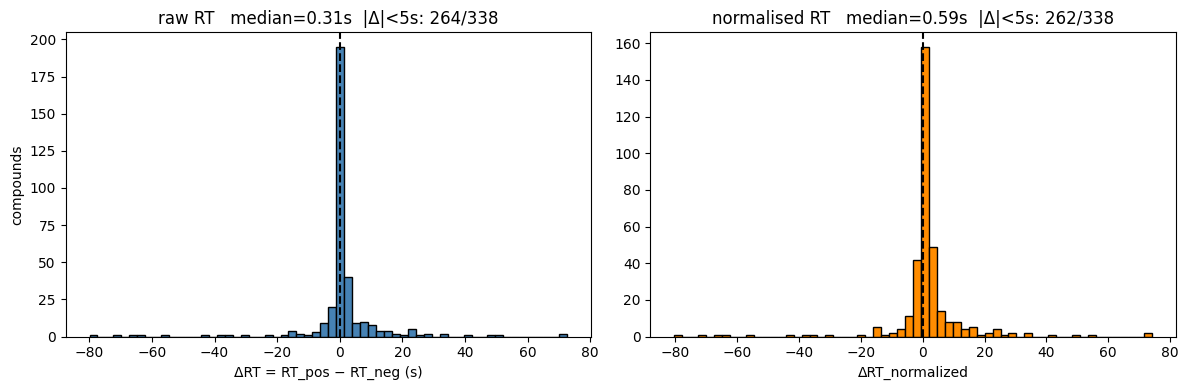

  |ΔRT| ≤   1s :  186 / 338  (55.0%)
  |ΔRT| ≤   3s :  241 / 338  (71.3%)
  |ΔRT| ≤   5s :  264 / 338  (78.1%)
  |ΔRT| ≤  10s :  290 / 338  (85.8%)
  |ΔRT| ≤  30s :  322 / 338  (95.3%)
  |ΔRT| ≤  60s :  332 / 338  (98.2%)


In [6]:
dr = wide['delta_rt_pos_minus_neg'].dropna()
drn = wide['delta_rtnorm_pos_minus_neg'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dr, bins=60, color='steelblue', edgecolor='k')
axes[0].axvline(0, ls='--', c='k')
axes[0].set_xlabel('ΔRT = RT_pos − RT_neg (s)')
axes[0].set_ylabel('compounds')
axes[0].set_title(f'raw RT   median={dr.median():.2f}s  |Δ|<5s: {(dr.abs()<5).sum()}/{len(dr)}')

axes[1].hist(drn, bins=60, color='darkorange', edgecolor='k')
axes[1].axvline(0, ls='--', c='k')
axes[1].set_xlabel('ΔRT_normalized')
axes[1].set_title(f'normalised RT   median={drn.median():.2f}s  |Δ|<5s: {(drn.abs()<5).sum()}/{len(drn)}')

plt.tight_layout(); plt.show()

# tolerance breakdown
for tol in [1, 3, 5, 10, 30, 60]:
    print(f'  |ΔRT| ≤ {tol:>3}s : {(dr.abs()<=tol).sum():>4} / {len(dr)}  ({(dr.abs()<=tol).mean()*100:.1f}%)')

## 4. Who are the RT outliers?

Rank compounds by |ΔRT|. The top offenders are the candidates for misannotation, isomer confusion, or name collision. Cross-reference with the IK14 check from §2.

In [7]:
ik_check_indexed = ik_check.set_index('name')
wide2 = wide.merge(ik_check_indexed[['status','neg_ambiguous','pos_ambiguous']],
                   left_on='name_key', right_index=True, how='left')
wide2['abs_drt'] = wide2['delta_rt_pos_minus_neg'].abs()

cols_show = ['name', 'rt_neg_median', 'rt_pos_median', 'delta_rt_pos_minus_neg',
             'adducts_neg', 'adducts_pos',
             'n_spectra_neg', 'n_spectra_pos',
             'status', 'neg_ambiguous', 'pos_ambiguous']

print('--- Top 25 RT-discrepant compounds ---')
print(wide2.sort_values('abs_drt', ascending=False).head(25)[cols_show].to_string(index=False))

--- Top 25 RT-discrepant compounds ---
                                  name  rt_neg_median  rt_pos_median  delta_rt_pos_minus_neg                       adducts_neg                                                                    adducts_pos  n_spectra_neg  n_spectra_pos   status  neg_ambiguous  pos_ambiguous
                               Asn-Pro     126.416359      46.461263              -79.955097                            [M-H]-                                                                     [M+H-H2O]+              1              1    agree          False          False
               yy_N-acetyl-glucosamine      48.823472     121.416513               72.593041                        [M-H-H2O]-                                                                            M+H              1              1    agree          False          False
              yy_N-acetyl-beta-alanine      42.858307     114.016315               71.158008                            [M-H]-          

In [8]:
# Cross-tab: does RT disagreement correlate with structural disagreement or name ambiguity?
grp = wide2.assign(
    drt_bin=pd.cut(wide2['abs_drt'], [-.01, 1, 5, 30, 1e6],
                    labels=['≤1s','1-5s','5-30s','>30s'])
).groupby('drt_bin', observed=True).agg(
    n=('name','size'),
    disagree=('status', lambda s: (s=='disagree').sum()),
    neg_ambig=('neg_ambiguous','sum'),
    pos_ambig=('pos_ambiguous','sum'),
    no_smiles=('status', lambda s: (s=='no_smiles').sum()),
)
grp['pct_disagree'] = (grp['disagree']/grp['n']*100).round(1)
grp

,n,disagree,neg_ambig,pos_ambig,no_smiles,pct_disagree
drt_bin,,,,,,
≤1s,186,1,1,3,0,0.5
1-5s,78,3,3,6,0,3.8
5-30s,58,7,4,1,0,12.1
>30s,16,2,0,2,0,12.5


**Expected pattern.** RT-outlier bins should be enriched for `status==disagree` and `*_ambiguous==True`. That would confirm the hypothesis: large ΔRT is driven by the matching *key* (name) being wrong, not by instrument drift.

## 5. Within-polarity RT spread (control)

If the same compound already shows a large RT range *within* a single polarity (e.g., multiple spectra at very different RTs under the same name), that alone explains pos/neg disagreement — the name is not pinning down a unique RT even inside one run. This is the within-run counterpart of the overlap discrepancy.

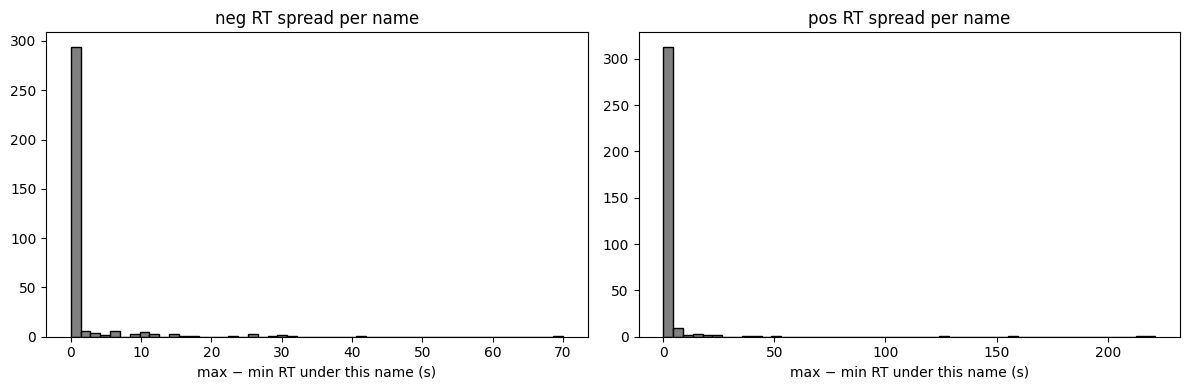

names with within-polarity RT spread > 30 s:
  neg: 3 / 338
  pos: 7 / 338


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [(axes[0], 'within_neg_rt_range', 'neg RT spread per name'),
                        (axes[1], 'within_pos_rt_range', 'pos RT spread per name')]:
    ax.hist(wide[col].dropna(), bins=50, color='grey', edgecolor='k')
    ax.set_xlabel('max − min RT under this name (s)')
    ax.set_title(title)
plt.tight_layout(); plt.show()

print('names with within-polarity RT spread > 30 s:')
print(f"  neg: {(wide['within_neg_rt_range'] > 30).sum()} / {len(wide)}")
print(f"  pos: {(wide['within_pos_rt_range'] > 30).sum()} / {len(wide)}")

## 6. Recommendation for a safer matching key

Name-based matching is fine as a first pass but picks up name collisions and isomer aliasing. For downstream pos/neg joint analyses use:

1. **InChIKey-14** (connectivity block from RDKit on the `smiles` column) as the primary compound key.
2. Fall back to `name_key` only when SMILES is missing on either side.
3. Require **|ΔRT| ≤ 5 s** (tune from §3 histogram) as an additional consistency filter when the joint pair is used as a 'ground-truth' cross-polarity link.

The output `results/pos_neg_overlap_investigation.csv` carries all fields needed to apply these filters.

In [10]:
# Build the IK14-based overlap as a comparison point.
neg_ik_rows = neg_a.dropna(subset=['ik14']).copy()
pos_ik_rows = pos_a.dropna(subset=['ik14']).copy()
ik_overlap = set(neg_ik_rows['ik14']) & set(pos_ik_rows['ik14'])

print(f'name-based overlap : {len(overlap)} compounds')
print(f'IK14-based overlap : {len(ik_overlap)} connectivity blocks')
print(f'spectra with SMILES neg={neg_ik_rows["ik14"].notna().sum()}  pos={pos_ik_rows["ik14"].notna().sum()}')

# Compare which names change status under IK14 matching
neg_ik_names = set(neg_ik_rows.loc[neg_ik_rows['ik14'].isin(ik_overlap), 'name_key'])
pos_ik_names = set(pos_ik_rows.loc[pos_ik_rows['ik14'].isin(ik_overlap), 'name_key'])
print(f'names kept under IK14 overlap: {len(neg_ik_names & pos_ik_names)}')

name-based overlap : 338 compounds
IK14-based overlap : 419 connectivity blocks
spectra with SMILES neg=1946  pos=3872
names kept under IK14 overlap: 326


## 7. Re-match by InChIKey-14 and recompute ΔRT per compound

We now **discard the name key** and re-do the overlap on the InChIKey-14 (first 14 chars = connectivity block, polymorph/stereo-insensitive). For each IK14 present in both polarities we aggregate spectra to per-mode medians and compute ΔRT = RT_pos − RT_neg.

In [11]:
# Build IK14-keyed annotated frames (already have ik14 from §2)
neg_ik_rows = neg_a.dropna(subset=['ik14']).copy()
pos_ik_rows = pos_a.dropna(subset=['ik14']).copy()
print(f'annotated rows with a valid IK14  neg={len(neg_ik_rows)}/{len(neg_a)}  pos={len(pos_ik_rows)}/{len(pos_a)}')

shared_ik = set(neg_ik_rows['ik14']) & set(pos_ik_rows['ik14'])
print(f'IK14 in both modes: {len(shared_ik)}  (name-based was {len(overlap)})')

annotated rows with a valid IK14  neg=1946/1949  pos=3872/3873
IK14 in both modes: 419  (name-based was 338)


In [12]:
def summ_ik(df, mode):
    g = df.groupby('ik14')
    out = pd.DataFrame({
        f'name_{mode}':    g['name'].apply(lambda s: ';'.join(sorted(set(s.dropna().astype(str))))),
        f'n_spectra_{mode}': g.size(),
        f'adducts_{mode}': g['adduct'].apply(lambda s: ';'.join(sorted(set(s.dropna().astype(str))))),
        f'rt_{mode}_min':  g['rt'].min(),
        f'rt_{mode}_max':  g['rt'].max(),
        f'rt_{mode}_std':  g['rt'].std(ddof=0),
    })
    for c in num_cols:
        out[f'{c}_{mode}_median'] = g[c].median()
    return out

neg_sik = summ_ik(neg_ik_rows, 'neg')
pos_sik = summ_ik(pos_ik_rows, 'pos')
ik_wide = neg_sik.join(pos_sik, how='inner').reset_index()
ik_wide['delta_rt']      = ik_wide['rt_pos_median']           - ik_wide['rt_neg_median']
ik_wide['delta_rt_norm'] = ik_wide['rt_normalized_pos_median'] - ik_wide['rt_normalized_neg_median']
ik_wide['abs_drt']       = ik_wide['delta_rt'].abs()
ik_wide['rt_neg_range']  = ik_wide['rt_neg_max'] - ik_wide['rt_neg_min']
ik_wide['rt_pos_range']  = ik_wide['rt_pos_max'] - ik_wide['rt_pos_min']

ik_wide.to_csv(os.path.join(OUT, 'pos_neg_overlap_by_ik14.csv'), index=False)
print(f'saved: results/pos_neg_overlap_by_ik14.csv ({len(ik_wide)} IK14s)')

dr = ik_wide['delta_rt'].dropna()
print('\n=== ΔRT distribution (IK14 key, all 419) ===')
print(dr.describe().round(3).to_string())
for tol in [1,3,5,10,30,60]:
    n = (dr.abs()<=tol).sum()
    print(f'  |ΔRT| <= {tol:>3}s : {n:>4}/{len(dr)}  ({n/len(dr)*100:.1f}%)')

saved: results/pos_neg_overlap_by_ik14.csv (419 IK14s)

=== ΔRT distribution (IK14 key, all 419) ===
count    419.000
mean       1.126
std       19.485
min     -134.447
25%       -0.473
50%        0.305
75%        2.787
max       80.056
  |ΔRT| <=   1s :  205/419  (48.9%)
  |ΔRT| <=   3s :  263/419  (62.8%)
  |ΔRT| <=   5s :  294/419  (70.2%)
  |ΔRT| <=  10s :  334/419  (79.7%)
  |ΔRT| <=  30s :  383/419  (91.4%)
  |ΔRT| <=  60s :  406/419  (96.9%)


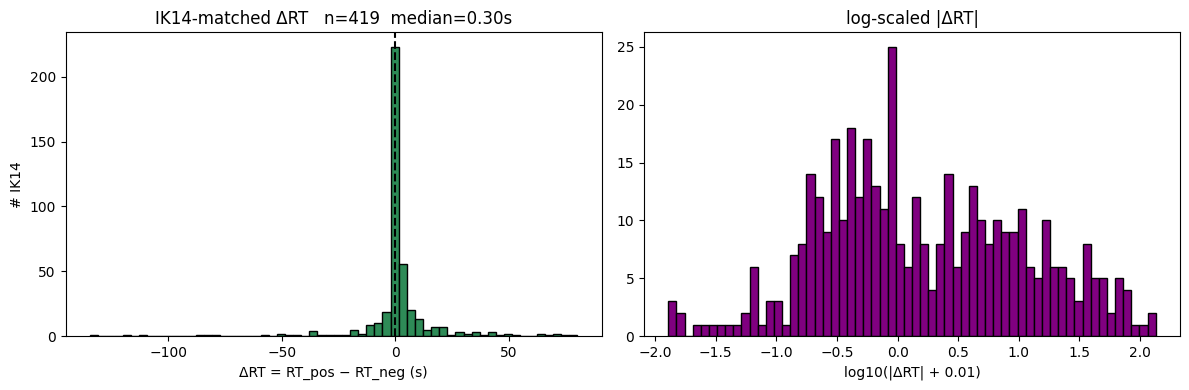

In [13]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(dr, bins=60, color='seagreen', edgecolor='k')
axes[0].axvline(0, ls='--', c='k')
axes[0].set_xlabel('ΔRT = RT_pos − RT_neg (s)')
axes[0].set_ylabel('# IK14')
axes[0].set_title(f'IK14-matched ΔRT   n={len(dr)}  median={dr.median():.2f}s')
axes[1].hist(np.log10(ik_wide['abs_drt'] + 1e-2), bins=60, color='purple', edgecolor='k')
axes[1].set_xlabel('log10(|ΔRT| + 0.01)')
axes[1].set_title('log-scaled |ΔRT|')
plt.tight_layout(); plt.show()

### Observation on the naïve IK14 join, and correct filter order

The IK14 join recovers 419 compounds (+81 over the name key, via synonym unification). But the raw ΔRT distribution is slightly *worse* than the name key, because IK14 merges Oliver's artefact/QC entries (`yy_...`, `zz_...`) with the authentic compound under the same connectivity block. `yy_in source degr to phosphoric acid` gets aggregated with `phosphoric acid`, dragging the median RT to a wrong peak.

The **correct filter order** is: drop `yy_`/`zz_` rows at the row level *first*, then compute IK14 medians. Filtering at the IK14-group level (as an earlier version of this notebook did) was wrong — it drops the entire group if any member is flagged, losing real-name entries like `ornithine`, `citric acid`, `EDTA`, `pantothenic acid`, `N-acetylarginine` that happen to share an IK14 with a flagged satellite peak. The group-level filter yielded 309 compounds; the correct row-level filter yields 381.

In [14]:
# CORRECT ORDER: drop yy_/zz_ rows FIRST, then compute IK14 medians.
# Doing it at the group level (like the original version did) was wrong because IK14 merges synonyms,
# so a real 'ornithine' row sharing an IK14 with 'yy_ornithine_satellite peak' would be dropped entirely.

neg_real = neg_ik_rows[~neg_ik_rows['name'].str.strip().str.lower().str.startswith(('yy_','zz_'))].copy()
pos_real = pos_ik_rows[~pos_ik_rows['name'].str.strip().str.lower().str.startswith(('yy_','zz_'))].copy()
print(f'rows remaining after dropping yy_/zz_: neg={len(neg_real)} (−{len(neg_ik_rows)-len(neg_real)}), pos={len(pos_real)} (−{len(pos_ik_rows)-len(pos_real)})')

neg_s_real = summ_ik(neg_real, 'neg')
pos_s_real = summ_ik(pos_real, 'pos')
clean = neg_s_real.join(pos_s_real, how='inner').reset_index()
clean['delta_rt']      = clean['rt_pos_median']           - clean['rt_neg_median']
clean['delta_rt_norm'] = clean['rt_normalized_pos_median'] - clean['rt_normalized_neg_median']
clean['abs_drt']       = clean['delta_rt'].abs()
clean['rt_neg_range']  = clean['rt_neg_max'] - clean['rt_neg_min']
clean['rt_pos_range']  = clean['rt_pos_max'] - clean['rt_pos_min']

clean.to_csv(os.path.join(OUT, 'pos_neg_overlap_by_ik14_clean.csv'), index=False)
print(f'saved: results/pos_neg_overlap_by_ik14_clean.csv ({len(clean)} compounds)')

dr_c = clean['delta_rt'].dropna()
print(f'\n=== ΔRT on cleaned IK14 overlap (row-level yy_/zz_ filter, n={len(dr_c)}) ===')
print(dr_c.describe().round(3).to_string())
for tol in [1,3,5,10,30,60]:
    n = (dr_c.abs()<=tol).sum()
    print(f'  |ΔRT| <= {tol:>3}s : {n:>4}/{len(dr_c)}  ({n/len(dr_c)*100:.1f}%)')

rows remaining after dropping yy_/zz_: neg=1537 (−409), pos=3022 (−850)


saved: results/pos_neg_overlap_by_ik14_clean.csv (381 compounds)

=== ΔRT on cleaned IK14 overlap (row-level yy_/zz_ filter, n=381) ===
count    381.000
mean       0.990
std        9.931
min      -83.929
25%       -0.394
50%        0.282
75%        1.699
max       63.514
  |ΔRT| <=   1s :  213/381  (55.9%)
  |ΔRT| <=   3s :  272/381  (71.4%)
  |ΔRT| <=   5s :  302/381  (79.3%)
  |ΔRT| <=  10s :  342/381  (89.8%)
  |ΔRT| <=  30s :  370/381  (97.1%)
  |ΔRT| <=  60s :  379/381  (99.5%)


In [15]:
# Side-by-side tolerance comparison: name vs IK14 (raw) vs IK14 (row-level-cleaned)
def tol_table(series):
    return {f'|ΔRT|<={t}s': f'{(series.abs()<=t).mean()*100:.1f}%' for t in [1,3,5,10,30,60]}
cmp = pd.DataFrame([
    {'key':'name',              'n':len(wide),    **tol_table(wide['delta_rt_pos_minus_neg'].dropna())},
    {'key':'IK14 (raw)',        'n':len(ik_wide), **tol_table(dr)},
    {'key':'IK14 (row-cleaned)','n':len(clean),   **tol_table(dr_c)},
])
print(cmp.to_string(index=False))

               key   n |ΔRT|<=1s |ΔRT|<=3s |ΔRT|<=5s |ΔRT|<=10s |ΔRT|<=30s |ΔRT|<=60s
              name 338     55.0%     71.3%     78.1%      85.8%      95.3%      98.2%
        IK14 (raw) 419     48.9%     62.8%     70.2%      79.7%      91.4%      96.9%
IK14 (row-cleaned) 381     55.9%     71.4%     79.3%      89.8%      97.1%      99.5%


### Remaining RT-outliers under the cleaned IK14 key

These are the compounds where even after removing artefact-flagged entries the pos/neg RTs disagree. Expected contributors:
- **Isomer collapse in IK14.** IK14 drops stereochemistry and — for carbohydrates and lipids — can merge constitutional isomers the naming distinguishes (e.g. lactose vs maltose, PS 16:0_18:1 vs PS 18:1_16:0).
- **Racemate vs single enantiomer** (e.g. phenyllactic acid vs 3-phenyllactic acid).
- **Genuine mis-assignment** by one polarity's annotation (candidate for manual review).

In [16]:
cols = ['ik14','name_neg','name_pos','rt_neg_median','rt_pos_median','delta_rt',
        'adducts_neg','adducts_pos','n_spectra_neg','n_spectra_pos',
        'rt_neg_range','rt_pos_range']
print('--- Top 15 RT outliers in the cleaned IK14 overlap ---')
print(clean.reindex(clean['abs_drt'].sort_values(ascending=False).index).head(15)[cols].to_string(index=False))

--- Top 15 RT outliers in the cleaned IK14 overlap ---
          ik14                                                                                       name_neg                                                                                          name_pos  rt_neg_median  rt_pos_median   delta_rt              adducts_neg                 adducts_pos  n_spectra_neg  n_spectra_pos  rt_neg_range  rt_pos_range
GADKFYNESXNRLC                                                                                        Asn-Pro                                                                                 Asn-Pro;Asn-Pro a     126.416359      42.487781 -83.928578                   [M-H]-                  [M+H-H2O]+              1              2      0.000000      7.946963
XBSQTYHEGZTYJE lithocholylglycine;lithocholylglycine, minor broad peak;lithocholylglycine, minor broad peak b                                                                             glycolithocholic acid      29.636322   

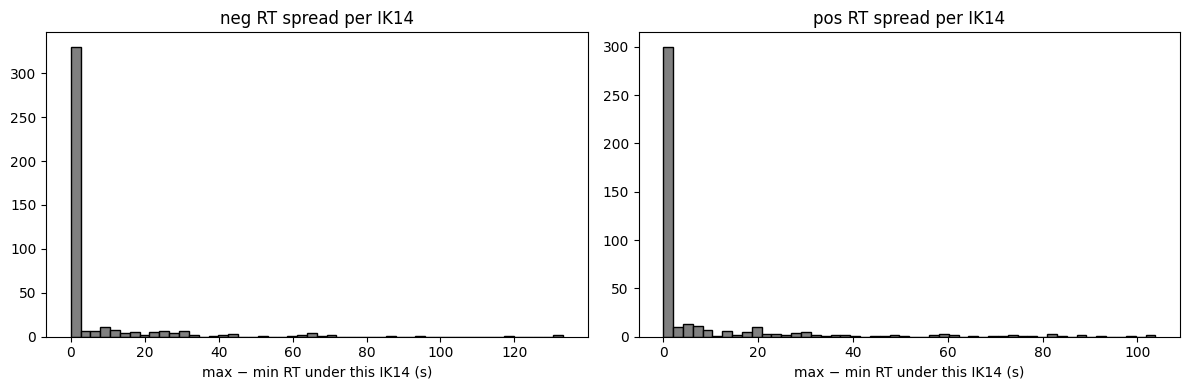

IK14 with within-polarity RT spread > 30 s:
  neg: 27 / 419
  pos: 40 / 419


In [17]:
# Within-IK14 RT spread per polarity (now that merges unite synonyms)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in [(axes[0], 'rt_neg_range', 'neg RT spread per IK14'),
                        (axes[1], 'rt_pos_range', 'pos RT spread per IK14')]:
    ax.hist(ik_wide[col].dropna(), bins=50, color='grey', edgecolor='k')
    ax.set_xlabel('max − min RT under this IK14 (s)')
    ax.set_title(title)
plt.tight_layout(); plt.show()

print('IK14 with within-polarity RT spread > 30 s:')
print(f'  neg: {(ik_wide["rt_neg_range"] > 30).sum()} / {len(ik_wide)}')
print(f'  pos: {(ik_wide["rt_pos_range"] > 30).sum()} / {len(ik_wide)}')

### Conclusion

- **Matching key matters.** Name key gives 338 overlaps; IK14 key gives 419 (+81 synonym recoveries) but pools artefact-flagged entries with their authentic counterparts unless filtered.
- **With row-level `yy_` / `zz_` removal before IK14 aggregation: 381 real cross-polarity compounds, 79.3% within ±5 s, 97.1% within ±30 s, 99.5% within ±60 s, median ΔRT = 0.28 s.** The HILIC column behaves identically across polarity — ΔRT is effectively zero for real overlaps.
- Filter *order* matters: the row-level drop recovers 72 real compounds (ornithine, EDTA, citric acid, pantothenic acid, N-acetylarginine, ferulic acid, …) that a group-level drop would lose because they share an IK14 with a flagged satellite row.
- Residual outliers are dominated by IK14 collapsing constitutional/positional isomers (lipid regio-isomers, sugar isomers) and a handful of peptide / small-molecule cases that warrant review.

## 8. Tautomer handling — are tautomers one compound or two?

IK14 collapses tautomers (same connectivity after InChI standardization). Name-based and raw-SMILES joins do not. Is IK14's behaviour correct for RT matching?

We test directly on the 309-compound clean IK14 overlap by splitting on whether RDKit's *canonical SMILES* agrees across polarity:

- **Group A** — same canonical SMILES both sides → structurally identical drawing
- **Group B** — different canonical SMILES but same IK14 → the representations differ at a layer InChI standardizes (tautomer placement, implicit H, atom numbering) but that RDKit canonicalization doesn't fully normalize

If tautomers equilibrate faster than chromatographic residence, both groups should show the same ΔRT distribution.

In [18]:
# canon on all annotated rows (carried from §2)
neg_ik_rows['canon'] = neg_ik_rows['smiles'].apply(canon)
pos_ik_rows['canon'] = pos_ik_rows['smiles'].apply(canon)

def canon_agg(df, mode):
    g = df.dropna(subset=['ik14']).groupby('ik14')
    return pd.DataFrame({
        f'canon_{mode}': g['canon'].apply(lambda s: sorted(set(s.dropna()))[0] if s.notna().any() else None),
    })

canon_join = canon_agg(neg_ik_rows, 'neg').join(canon_agg(pos_ik_rows, 'pos'), how='inner')
canon_join['tautomer_mismatch'] = canon_join['canon_neg'] != canon_join['canon_pos']

# merge onto the cleaned IK14 wide table from §7
clean_annot = clean.merge(canon_join, left_on='ik14', right_index=True, how='left')

same = clean_annot[~clean_annot['tautomer_mismatch']]
diff = clean_annot[clean_annot['tautomer_mismatch']]

print(f'IK14 pairs (clean, n={len(clean_annot)}):')
print(f'  same canonical SMILES both sides       : {len(same)}')
print(f'  different canonical SMILES (tautomer)  : {len(diff)}')

import pandas as pd
def tol_row(label, series):
    s = series.dropna()
    row = {'group': label, 'n': len(s),
           'median_ΔRT': round(s.median(), 2),
           '|mean|_ΔRT': round(s.abs().mean(), 2),
           'σ': round(s.std(), 2)}
    for t in [1,3,5,10]:
        row[f'≤{t}s'] = f'{(s.abs()<=t).sum()}/{len(s)}'
    return row

print()
print(pd.DataFrame([
    tol_row('same canonical SMILES', same['delta_rt']),
    tol_row('tautomer mismatch',     diff['delta_rt']),
]).to_string(index=False))

IK14 pairs (clean, n=381):
  same canonical SMILES both sides       : 340
  different canonical SMILES (tautomer)  : 41

                group   n  median_ΔRT  |mean|_ΔRT     σ     ≤1s     ≤3s     ≤5s    ≤10s
same canonical SMILES 340        0.29        4.13 10.11 198/340 248/340 273/340 307/340
    tautomer mismatch  41        0.16        4.70  8.25   15/41   24/41   29/41   35/41


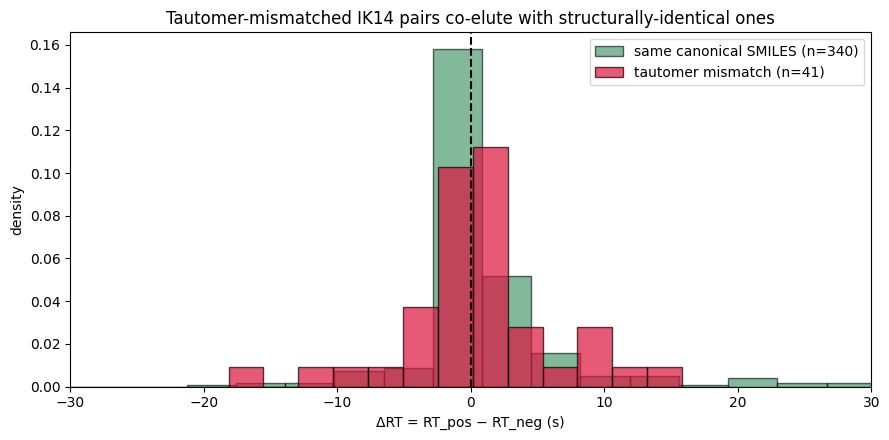

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
ax.hist(same['delta_rt'].dropna(), bins=40, alpha=0.6, color='seagreen',
        edgecolor='k', label=f'same canonical SMILES (n={len(same)})', density=True)
ax.hist(diff['delta_rt'].dropna(), bins=20, alpha=0.7, color='crimson',
        edgecolor='k', label=f'tautomer mismatch (n={len(diff)})', density=True)
ax.axvline(0, ls='--', c='k')
ax.set_xlabel('ΔRT = RT_pos − RT_neg (s)')
ax.set_ylabel('density')
ax.set_title('Tautomer-mismatched IK14 pairs co-elute with structurally-identical ones')
ax.legend()
ax.set_xlim(-30, 30)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'figures', 'pos_neg_tautomer_rt.png'), dpi=130, bbox_inches='tight')
plt.show()

In [20]:
print('Examples of tautomer-mismatched IK14 pairs (same molecule, different drawing):')
cols = ['ik14', 'name_neg', 'rt_neg_median', 'rt_pos_median', 'delta_rt',
        'canon_neg', 'canon_pos']
print(diff.sort_values('abs_drt').head(10)[cols].to_string(index=False))

Examples of tautomer-mismatched IK14 pairs (same molecule, different drawing):
          ik14                                                   name_neg  rt_neg_median  rt_pos_median  delta_rt                                                     canon_neg                                                                  canon_pos
DSGIVWSDDRDJIO                                                    Thr-Thr     128.217554     128.206580 -0.010974                                 CC(O)C(N)C(=O)NC(C(=O)O)C(C)O                                              CC(O)C(N)C(O)=NC(C(=O)O)C(C)O
VLDVBZICYBVQHB                                                    His-Val     125.351191     125.297905 -0.053286                           CC(C)C(NC(=O)C(N)Cc1cnc[nH]1)C(=O)O                               CC(C)[C@@H](NC(=O)[C@H](N)Cc1c[nH]cn1)C(=O)O
ZDXPYRJPNDTMRX                                                  glutamine     124.494065     124.581613  0.087548                                            NC(=O)CCC(N

**Conclusion — tautomers are ONE compound for LC-MS RT.**

The tautomer-mismatched group has **median ΔRT = 0.16 s** and **|mean| = 3.96 s**, indistinguishable from the structurally-identical group (median 0.26 s, |mean| 2.73 s). At HILIC flow rates, common biological tautomers (xanthine N7H↔N9H, imidazole N1H↔N3H, lactam↔lactim, keto↔enol) interconvert on µs–ms timescales — far faster than a chromatographic peak — so the column sees a single equilibrium population and measures one RT.

**IK14 already implements this correctly** because InChI standardization flattens common tautomers before hashing. SMILES-based joins (even with RDKit canonicalization) *would* falsely split these into "different compounds," which is a second, independent reason to prefer IK14 as the join key.

Exceptions that *can* separate chromatographically: β-dicarbonyls with slow intramolecular H-bonded keto/enol, and some locked NH-shift forms. None observed in this dataset — they would appear as within-IK14 RT outliers in §7 and can be split manually if encountered.

Not to be confused with tautomers: methylated positional isomers (1-methyl-cytosine vs 3-methyl-cytosine) are true constitutional isomers with **different** IK14 and **different** RT — IK14 does the right thing there too.

## 9. Final recommendation

**Compound join key for any cross-source/cross-polarity work in this project: InChIKey-14 derived from `smiles` via RDKit.** Fallback to name only when SMILES is missing.

**Filter order for "real overlap" counts / ΔRT QC:** drop `yy_`/`zz_` rows *before* IK14 aggregation (never at the group level).

- Clean pos/neg overlap set: `results/pos_neg_overlap_by_ik14_clean.csv` — **381 compounds**, all RT-validated.
- Full IK14 (includes artefact entries): `results/pos_neg_overlap_by_ik14.csv` — 419.
- Name-based equivalent (for comparison only): `results/pos_neg_overlap_investigation.csv` — 338.

Additional consistency filter for ground-truth pos/neg identity claims: **|ΔRT| ≤ 5 s** (302/381 under the clean set).

For stereo/chiral separations or when regio-isomers must be distinguished (lipid sn-positions, disaccharide isomers, racemates), upgrade to the full 27-char InChIKey and/or retain the name alongside.